# Single Phase Diffusion

## Example - NiCrAl System

Along with precipitation, kawin also supports one dimensional diffusion models. In this example, a diffusion couple will be simulated between two different NiCrAl compositions. Both phases will be FCC.

Note: Fluxes are calculated on a volume fixed frame of reference. In this frame of reference, the location of the Matano plane is fixed. If a lattice fixed frame of reference is used, then the movement of the Matano plane would move (this would be similar to the Smigelskas–Kirkendall experiments).

## Setup

The diffusion model handles the mesh creation and interfaces with the Thermodynamics module to compute fluxes from mobility and the curvature of the Gibbs free energy surface

Loading the Thermodynamics object is the same as done for creating a precipitation model. The GeneralThermodynamics object can be used here since the functions necessary for the diffusion model are the same for binary and multicomponent systems.

In [ ]:
from kawin.thermo import GeneralThermodynamics

therm = GeneralThermodynamics('FeCrNi_Lee1993_L_style_ternary_checked_withMobility.tdb', ['FE', 'CR', 'NI'], ['FCC_A1'])
therm.elements

['CR', 'FE', 'NI', 'VA']

CPU times: total: 4.28 s
Wall time: 4.37 s


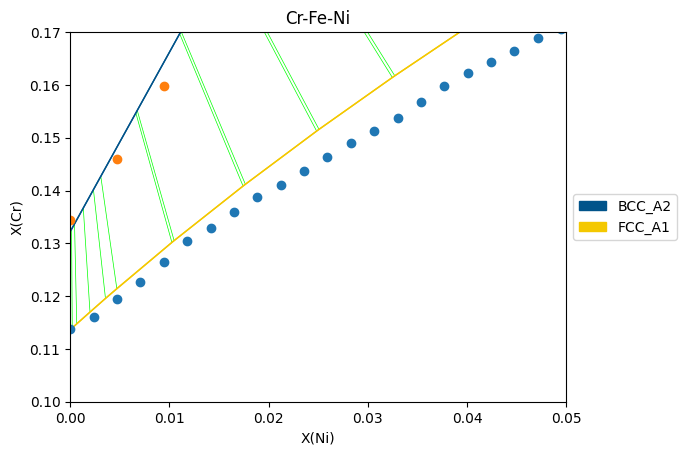

In [11]:
from pycalphad import Database, ternplot
from pycalphad import variables as v
import matplotlib.pyplot as plt

db_fe_cr_ni = Database('FeCrNi.tdb')
comps = ['FE', 'CR', 'NI', 'VA']
phases = list(db_fe_cr_ni.phases.keys())
conds = {v.T: 1373, v.P:101325, v.X('NI'): (0,1,0.015), v.X('CR'): (0,1,0.015)}

fig, ax = plt.subplots()
%time out=ternplot(db_fe_cr_ni, comps, phases, conds, x=v.X('NI'), y=v.X('CR'), ax=ax)


import pandas as pd
FCC_extractedPts_df = pd.read_csv("leeAndOh1996_data\\FCClineAt1373FromWPDcsv.csv", names=['W(NI)', 'W(CR)'])
BCC_extractedPts_df = pd.read_csv("leeAndOh1996_data\\BCClineAt1373FromWPDcsv.csv", names=['W(NI)', 'W(CR)'])
FCC_extractedPts_df = FCC_extractedPts_df/100
BCC_extractedPts_df = BCC_extractedPts_df/100

def convertNiCrWtToMoleFracs(df_input):
    df = pd.DataFrame.from_dict(df_input.apply(lambda row: v.get_mole_fractions({v.W('CR'): row['W(CR)'], v.W('NI'): row['W(NI)']}, dependent_species='FE', pure_element_mass_dict=db_fe_cr_ni), axis=1).to_list(), orient='columns')
    df.columns = df.columns.astype(str)
    df_input[['X_NI', 'X_CR']] = df[['X_NI', 'X_CR']].copy()
    return df_input

FCC_extractedPts_df = convertNiCrWtToMoleFracs(FCC_extractedPts_df)
BCC_extractedPts_df = convertNiCrWtToMoleFracs(BCC_extractedPts_df)


ax.set_xlim(0, 0.05); ax.set_ylim(0.1, 0.17)
ax.plot(FCC_extractedPts_df['X_NI'], FCC_extractedPts_df['X_CR'], 'o', label='FCC extracted points')
ax.plot(BCC_extractedPts_df['X_NI'], BCC_extractedPts_df['X_CR'], 'o', label='BCC extracted points')

CPU times: total: 4.44 s
Wall time: 4.48 s


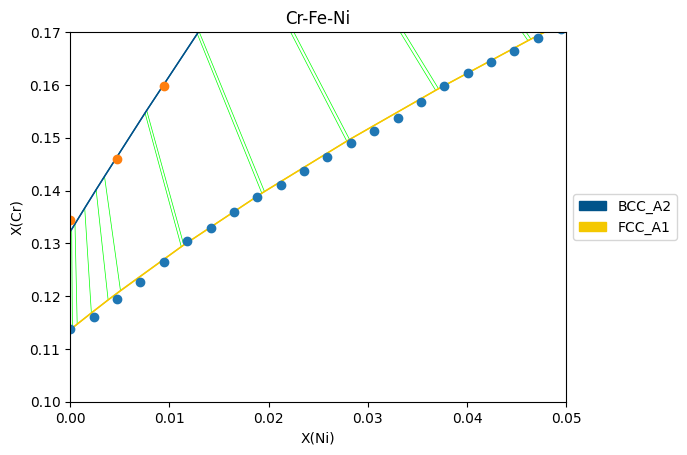

In [ ]:
from pycalphad import Database, ternplot
from pycalphad import variables as v
import matplotlib.pyplot as plt

db_fe_cr_ni = Database('FeCrNi_Lee1993_L_style_ternary_checked_withMobility.tdb')
comps = ['FE', 'CR', 'NI', 'VA']
phases = list(db_fe_cr_ni.phases.keys())
conds = {v.T: 1373, v.P:101325, v.X('NI'): (0,1,0.015), v.X('CR'): (0,1,0.015)}

fig, ax = plt.subplots()
%time out=ternplot(db_fe_cr_ni, comps, phases, conds, x=v.X('NI'), y=v.X('CR'), ax=ax)

# if isinstance(out, tuple):
#     fig, ax = out
# else:
#     ax = out

ax.set_xlim(0, 0.05); ax.set_ylim(0.1, 0.17)
ax.plot(FCC_extractedPts_df['X_NI'], FCC_extractedPts_df['X_CR'], 'o', label='FCC extracted points')
ax.plot(BCC_extractedPts_df['X_NI'], BCC_extractedPts_df['X_CR'], 'o', label='BCC extracted points')

In [ ]:
from pycalphad import Database, equilibrium, variables as v
from pycalphad.codegen.sympydiff_utils import build_functions
from kawin.thermo.Thermodynamics import GeneralThermodynamics
from kawin.thermo.Mobility import MobilityModel, mobility_from_composition_set, tracer_diffusivity



# -----------------------------
# Placeholder inputs
# -----------------------------
tdb_file = "FeCrNi_Lee1993_L_style_ternary_checked_withMobility.tdb"
elements = ["CR", "FE", "NI", "VA"]          # ternary substitutional alloy with vacancy
phase_name = "FCC_A1"             # placeholder phase name
T = 1373.0                        # K
x_FE = 0.7                        # mole fraction of B
x_NI = 0.15                        # mole fraction of C
x = [0.15, 0.7]              # composition vector in element order
x_alt = [0.33, 0.34]              # composition vector in element order
P = 101325                        # Pa

# -----------------------------
# Load database
# -----------------------------
thermo = GeneralThermodynamics(
    database=tdb_file,
    elements=elements,
    phases=phases
)

# Local single-phase equilibrium -> returns composition sets directly
result, comp_sets = thermo.getLocalEq(x, T, precPhase=["BCC_A2"])

cs = comp_sets[0]
phase = "BCC_A2"



M = mobility_from_composition_set(
    cs,
    mobility_callables=thermo.mobCallables[phase],
    mobility_correction=thermo.mobility_correction,
    parameters=thermo._parameters
)

print("phase:", cs.phase_record.phase_name)
print("elements in callable order:", list(cs.phase_record.nonvacant_elements))
print("mobilities:", M)




# Local single-phase equilibrium -> returns composition sets directly
result, comp_sets = thermo.getLocalEq(x_alt, T, precPhase=["BCC_A2"])

cs = comp_sets[0]
phase = "BCC_A2"



M = mobility_from_composition_set(
    cs,
    mobility_callables=thermo.mobCallables[phase],
    mobility_correction=thermo.mobility_correction,
    parameters=thermo._parameters
)

print("phase:", cs.phase_record.phase_name)
print("elements in callable order:", list(cs.phase_record.nonvacant_elements))
print("mobilities:", M)



phase: BCC_A2
elements in callable order: ['CR', 'FE', 'NI']
mobilities: [2.07616934e-17 1.03808467e-17 3.11425401e-18]
phase: BCC_A2
elements in callable order: ['CR', 'FE', 'NI']
mobilities: [2.07616934e-17 1.03808467e-17 3.11425401e-18]


In [ ]:
''' Calculate explicitly to prove the formula/values give the same result as mobility_from_composition_set: '''

MQ_BCC_CR_CR = -240000
MF_BCC_CR_CR = R*T*np.log(3.2E-4)
MQ_BCC_CR_FE = MQ_BCC_CR_CR; MF_BCC_CR_FE = MF_BCC_CR_CR
MQ_BCC_CR_NI = MQ_BCC_CR_CR; MF_BCC_CR_NI = MF_BCC_CR_CR

MQ_BCC_FE_CR = -240000
MF_BCC_FE_CR = R*T*np.log(1.6E-4)
MQ_BCC_FE_FE = MQ_BCC_FE_CR; MF_BCC_FE_FE = MF_BCC_FE_CR
MQ_BCC_FE_NI = MQ_BCC_FE_CR; MF_BCC_FE_NI = MF_BCC_FE_CR

MQ_BCC_NI_CR = -240000
MF_BCC_NI_CR = R*T*np.log(4.8E-5)
MQ_BCC_NI_FE = MQ_BCC_NI_CR; MF_BCC_NI_FE = MF_BCC_NI_CR
MQ_BCC_NI_NI = MQ_BCC_NI_CR; MF_BCC_NI_NI = MF_BCC_NI_CR

def calcMob(comp_dict):
    x_CR = comp_dict['CR']
    x_FE = comp_dict['FE']
    x_NI = comp_dict['NI']

    mob_CR = np.exp(((MQ_BCC_CR_CR*x_CR + MQ_BCC_CR_FE*x_FE + MQ_BCC_CR_NI*x_NI) + (MF_BCC_CR_CR*x_CR + MF_BCC_CR_FE*x_FE + MF_BCC_CR_NI*x_NI))/R/T) * 1/(R*T)
    mob_FE = np.exp(((MQ_BCC_FE_CR*x_CR + MQ_BCC_FE_FE*x_FE + MQ_BCC_FE_NI*x_NI) + (MF_BCC_FE_CR*x_CR + MF_BCC_FE_FE*x_FE + MF_BCC_FE_NI*x_NI))/R/T) * 1/(R*T)
    mob_NI = np.exp(((MQ_BCC_NI_CR*x_CR + MQ_BCC_NI_FE*x_FE + MQ_BCC_NI_NI*x_NI) + (MF_BCC_NI_CR*x_CR + MF_BCC_NI_FE*x_FE + MF_BCC_NI_NI*x_NI))/R/T) * 1/(R*T)

    return float(mob_CR), float(mob_FE), float(mob_NI)

# calcMob({'CR': 0.15, 'FE': 0.7, 'NI': 0.15})
calcMob({'CR': 0.33, 'FE': 0.33, 'NI': 0.34})

(2.0761693432064583e-17, 1.0380846716032307e-17, 3.1142540148096927e-18)

In [44]:
## Mobilities From Lee and Oh Paper
import numpy as np
R=8.3145  # J/(mol*K)
def calcPaperMobilities(comp_dict, T):
    # Placeholder function to calculate mobilities based on the Lee and Oh paper
    # This is a mock function and should be replaced with actual calculations
    # paperMobFunc = lambda A, B: A * np.exp(B / (R*T))  * 1/(R*T)
    paperMobFunc = lambda A, B: np.exp(np.log(A) + B / (R*T))  * 1/(R*T)

    BCC_mobilities = {} ## alpha phase
    for element, fraction in comp_dict.items():
        if element == "CR":
            BCC_mobilities[element] = paperMobFunc(3.2e-4, -240000)
        elif element == "FE":
            BCC_mobilities[element] = paperMobFunc(1.6e-4, -240000)  # Mock mobility for FE
        elif element == "NI":
            BCC_mobilities[element] = paperMobFunc(4.8e-5, -240000)  # Mock mobility for NI
        else:
            BCC_mobilities[element] = 0.0  # No mobility for other elements
    
    FCC_mobilities = {} ## alpha phase
    for element, fraction in comp_dict.items():
        if element == "CR":
            FCC_mobilities[element] = paperMobFunc(3.5e-4, -286000)  # Mock mobility for CR
        elif element == "FE":
            FCC_mobilities[element] = paperMobFunc(7.0e-5, -286000)  # Mock mobility for FE
        elif element == "NI":
            FCC_mobilities[element] = paperMobFunc(3.5e-5, -286000)  # Mock mobility for NI
        else:
            FCC_mobilities[element] = 0.0  # No mobility for other elements
    return {'BCC': BCC_mobilities, 'FCC': FCC_mobilities}

[float(n) for n in list(list(calcPaperMobilities({'CR': 0.15, 'FE': 0.7, 'NI': 0.15}, T=1373).values())[0].values())]
# calcPaperMobilities({'CR': 0.33, 'FE': 0.33, 'NI': 0.34}, T=1373)

[2.0761693432064583e-17, 1.0380846716032307e-17, 3.1142540148096927e-18]

The next step is to create the diffusion model. The model requires the z-coordinates, elements and phases upon initialization. Initial conditions can be added with the composition either as a step function, linear function, delta function or a user-defined function. Finally, boundary conditions are assumed to be no-flux conditions; however, constant flux or composition may also be defined.

Defining the initial and boundary conditions must specify the element it is being applied to.

Here, a diffusion couple composed of Ni-7.7Cr-5.4Al / Ni-35.9Cr-6.2Al will be used.

Plotting functions are stored in the diffusion object and can be used to look at the initial conditions.

In [187]:
fig12b_lowestCrGammaCurve_df = pd.read_csv("leeAndOh1996_data\\fig12b_lowestCrGammaCurve.csv", names=['W(NI)', 'W(CR)'])
fig12b_lowestCrGammaCurve_df = fig12b_lowestCrGammaCurve_df/100
fig12b_lowestCrGammaCurve_df = convertNiCrWtToMoleFracs(fig12b_lowestCrGammaCurve_df)
fig12b_lowestCrGammaCurve_df['X_FE'] = 1-fig12b_lowestCrGammaCurve_df['X_NI']-fig12b_lowestCrGammaCurve_df['X_CR']
fig12b_lowestCrGammaCurve_df.iloc[[0, -1]]

fig12b_highestCrGammaCurve_df = pd.read_csv("leeAndOh1996_data\\fig12b_highestCrGammaCurve.csv", names=['W(NI)', 'W(CR)'])
fig12b_highestCrGammaCurve_df = fig12b_highestCrGammaCurve_df/100
fig12b_highestCrGammaCurve_df = convertNiCrWtToMoleFracs(fig12b_highestCrGammaCurve_df)
fig12b_highestCrGammaCurve_df['X_FE'] = 1-fig12b_highestCrGammaCurve_df['X_NI']-fig12b_highestCrGammaCurve_df['X_CR']
fig12b_highestCrGammaCurve_df.iloc[[0, -1]]

fig12b_1hrCurve_df = pd.read_csv("leeAndOh1996_data\\fig12b_1hrCurve.csv", names=['W(NI)', 'W(CR)'])
fig12b_1hrCurve_df = fig12b_1hrCurve_df/100
fig12b_1hrCurve_df = convertNiCrWtToMoleFracs(fig12b_1hrCurve_df)
fig12b_1hrCurve_df['X_FE'] = 1-fig12b_1hrCurve_df['X_NI']-fig12b_1hrCurve_df['X_CR']
fig12b_1hrCurve_df.iloc[[0, -1]]

fig12b_10hrCurve_df = pd.read_csv("leeAndOh1996_data\\fig12b_10hrCurve.csv", names=['W(NI)', 'W(CR)'])
fig12b_10hrCurve_df = fig12b_10hrCurve_df/100
fig12b_10hrCurve_df = convertNiCrWtToMoleFracs(fig12b_10hrCurve_df)
fig12b_10hrCurve_df['X_FE'] = 1-fig12b_10hrCurve_df['X_NI']-fig12b_10hrCurve_df['X_CR']
fig12b_10hrCurve_df.iloc[[0, -1]]

fig12b_100hrCurve_df = pd.read_csv("leeAndOh1996_data\\fig12b_100hrCurve.csv", names=['W(NI)', 'W(CR)'])
fig12b_100hrCurve_df = fig12b_100hrCurve_df/100
fig12b_100hrCurve_df = convertNiCrWtToMoleFracs(fig12b_100hrCurve_df)
fig12b_100hrCurve_df['X_FE'] = 1-fig12b_100hrCurve_df['X_NI']-fig12b_100hrCurve_df['X_CR']
fig12b_100hrCurve_df.iloc[[0, -1]]

fig12b_1000hrCurve_df = pd.read_csv("leeAndOh1996_data\\fig12b_1000hrCurve.csv", names=['W(NI)', 'W(CR)'])
fig12b_1000hrCurve_df = fig12b_1000hrCurve_df/100
fig12b_1000hrCurve_df = convertNiCrWtToMoleFracs(fig12b_1000hrCurve_df)
fig12b_1000hrCurve_df['X_FE'] = 1-fig12b_1000hrCurve_df['X_NI']-fig12b_1000hrCurve_df['X_CR']
fig12b_1000hrCurve_df.iloc[[0, -1]]



,W(NI),W(CR),X_NI,X_CR,X_FE
0,0.052219,0.253317,0.048896,0.267733,0.683371
56,0.150113,0.129574,0.142510,0.138848,0.718643


(0.0, 0.25)

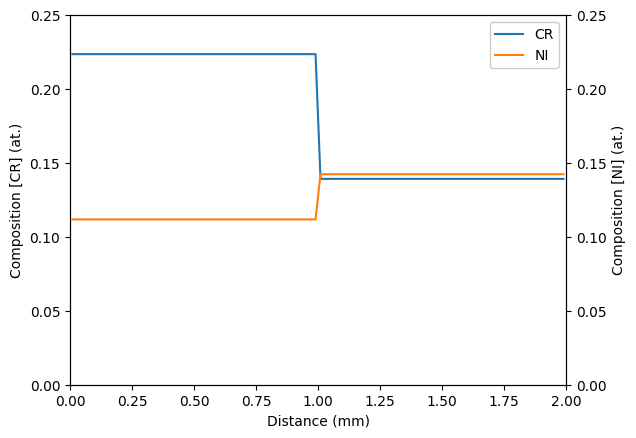

In [ ]:
import matplotlib.pyplot as plt
from kawin.diffusion import SinglePhaseModel
from kawin.diffusion.mesh import ProfileBuilder, StepProfile1D, Cartesian1D
from kawin.diffusion.Plot import plot1D, plot1DTwoAxis

from kawin.thermo import GeneralThermodynamics
therm = GeneralThermodynamics('FeCrNi_Lee1993_L_style_ternary_checked_withMobility.tdb', ['FE', 'CR', 'NI'], ['FCC_A1'])
therm.elements

#Define mesh spanning between -1mm to 1mm with 100 volume elements
mesh = Cartesian1D(['CR', 'NI'], [0, 2e-3], 100)

profile = ProfileBuilder()
# profile.addBuildStep(StepProfile1D(1e-3, [0.077, 0.054], [0.359, 0.062]), ['CR', 'AL'])
profile.addBuildStep(StepProfile1D(1e-3, [fig12b_highestCrGammaCurve_df['X_CR'].iloc[0], fig12b_highestCrGammaCurve_df['X_NI'].iloc[0]], [fig12b_highestCrGammaCurve_df['X_CR'].iloc[-1], fig12b_highestCrGammaCurve_df['X_NI'].iloc[-1]]), ['CR', 'NI'])
mesh.setResponseProfile(profile)

temperature = 1373
m = SinglePhaseModel(mesh, ['FE', 'CR', 'NI'], ['FCC_A1'], 
                     thermodynamics=therm, temperature=temperature, record=True)

# fig, ax = plt.subplots()
# plot1D(m, ['CR', 'NI'], zScale=1e-3, ax=ax)
# ax.set_xlabel('Distance (mm)')
# ax.set_ylim([0, 0.25])

fig, axL = plt.subplots()
axR = axL.twinx()
plot1DTwoAxis(m, 'CR', 'NI', zScale=1e-3, axL=axL, axR=axR)
axL.set_xlabel('Distance (mm)')
axL.set_ylim([0, 0.25])
axR.set_ylim([0, 0.25])

In addition to the initial and boundary conditions, the temperature and Thermodynamics object must be supplied to the diffusion model.

Similar to the precipitation model, progress on the simulation can be outputted by setting verbose to True and setting vIt to the number of iterations before a status update on the model is outputted.

In [155]:
from kawin.solver import explicitEulerIterator
t_hr=10000
m.solve(t_hr*3600, iterator=explicitEulerIterator, verbose=True, vIt=100)

Iteration	Sim Time (h)	Run time (s)
0		0.0e+00		0.0
100		2.7e+03		19.9
200		5.3e+03		24.2
300		8.0e+03		25.6
376		1.0e+04		26.2


### Plotting

Plotting the final composition profile is the same as plotting the initial profile.

(0.0, 0.25)

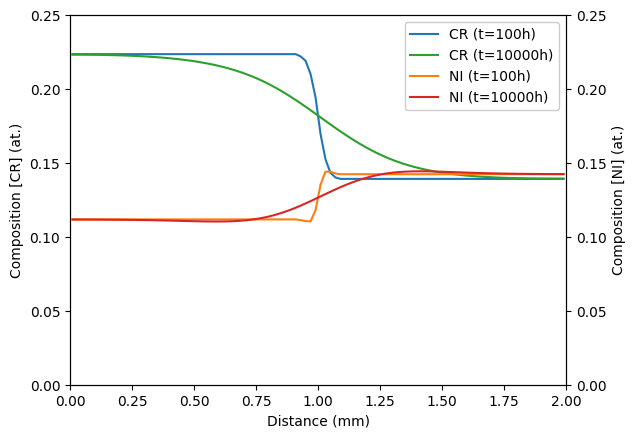

In [156]:
fig, axL = plt.subplots()
axR = axL.twinx()

# Plot at 20 hours
plot1DTwoAxis(m, 'CR', 'NI', zScale=1e-3, axL=axL, axR=axR, 
              time=100*3600, 
              label={'CR': 'CR (t=100h)', 'NI': 'NI (t=100h)'})

# Plot at final time
plot1DTwoAxis(m, 'CR', 'NI', zScale=1e-3, axL=axL, axR=axR, 
              time=t_hr*3600,
              label={'CR': f'CR (t={t_hr}h)', 'NI': f'NI (t={t_hr}h)'}, 
              color={'CR': 'C2', 'NI': 'C3'})
axL.set_xlabel('Distance (mm)')
axL.set_ylim([0, 0.25])
axR.set_ylim([0, 0.25])

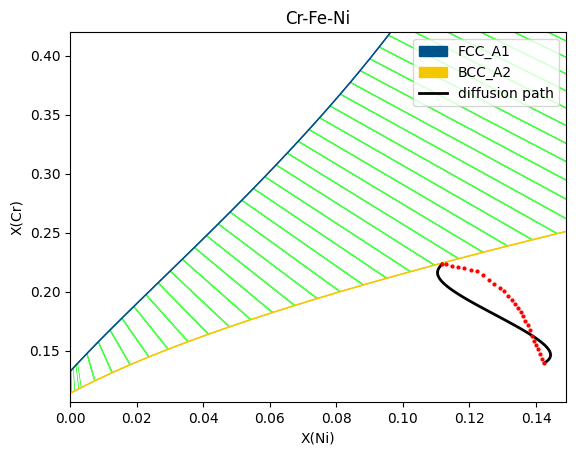

({X_CR: 0.10661669953475586, X_NI: 0.0},
 {X_CR: 0.42042856418330865, X_NI: 0.1489903126479831})

In [ ]:
import matplotlib.pyplot as plt
from pycalphad import ternplot, variables as v
from pycalphad.plot.utils import phase_legend

# fig = plt.figure(figsize=(6, 6))
fig, ax = plt.subplots()
# ax = fig.add_subplot(projection='triangular')

conds = {
    v.T: temperature,
    v.P: 101325,
    v.X('CR'): (0, 1, 0.01),
    v.X('NI'): (0, 1, 0.01),
}

ternplot(
    therm.db,
    ['FE', 'CR', 'NI', 'VA'],
    ['FCC_A1', 'BCC_A2'],
    conds,
    x=v.X('NI'),
    y=v.X('CR'),
    ax=ax
)

comp = m.getCompositions()

# Kawin docs note that getCompositions() includes all elements:
# dependent first, then independent ones.
# For elements ['FE', 'CR', 'NI'], that means:
# comp[:,0] -> FE, comp[:,1] -> CR, comp[:,2] -> NI
# ln, = ax.plot(comp[:, 1], comp[:, 2], lw=2, label='diffusion path')
ln, = ax.plot(comp[:, 2], comp[:, 1], lw=2, color='black', label='diffusion path')

handles, _ = phase_legend(['FCC_A1', 'BCC_A2'])
ax.legend(handles=handles + [ln])

ax.plot(fig12b_highestCrGammaCurve_df['X_NI'], fig12b_highestCrGammaCurve_df['X_CR'], 'o', markersize=2, color='red', label='Highest CR Gamma Curve')


ax.set_xlim(0, 0.149); ax.set_ylim(0.1066, 0.42)
plt.show()

v.get_mole_fractions({v.W('CR'): 0.1, v.W('NI'): 0.0}, dependent_species='FE', pure_element_mass_dict=db_fe_cr_ni), v.get_mole_fractions({v.W('CR'): 0.4, v.W('NI'): 0.16}, dependent_species='FE', pure_element_mass_dict=db_fe_cr_ni)

Iteration	Sim Time (h)	Run time (s)
0		0.0e+00		0.0
100		3.2e+02		74.4
200		6.5e+02		76.4
300		9.7e+02		77.0
308		1.0e+03		77.1


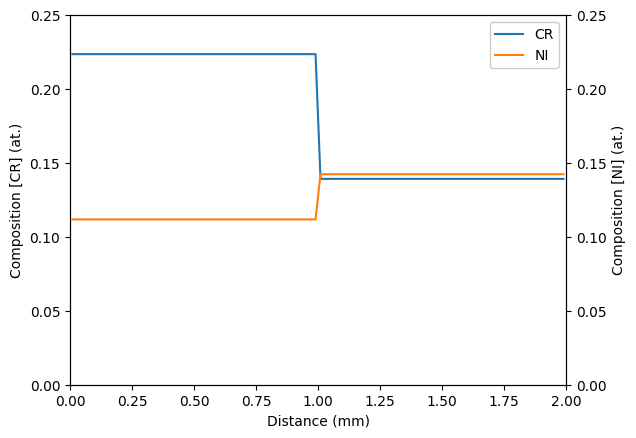

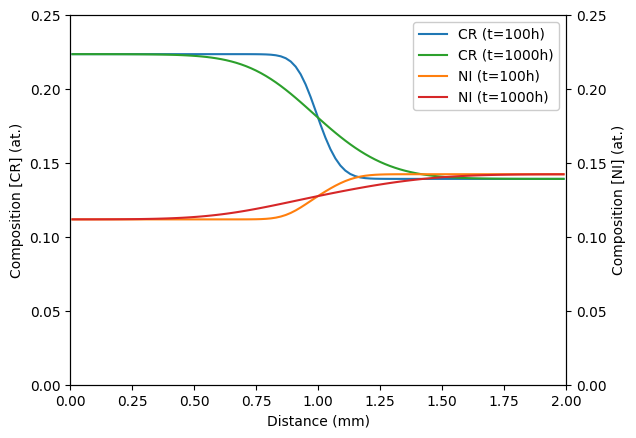

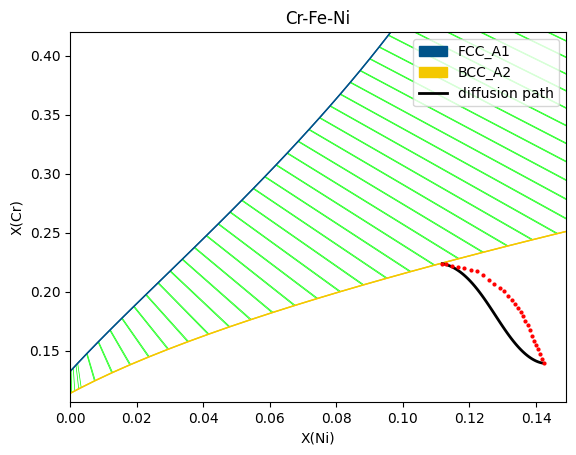

({X_CR: 0.10661669953475586, X_NI: 0.0},
 {X_CR: 0.42042856418330865, X_NI: 0.1489903126479831})

In [ ]:
import matplotlib.pyplot as plt
from kawin.diffusion import SinglePhaseModel
from kawin.diffusion.mesh import ProfileBuilder, StepProfile1D, Cartesian1D
from kawin.diffusion.Plot import plot1D, plot1DTwoAxis

from kawin.thermo import GeneralThermodynamics
therm_alt = GeneralThermodynamics('FeCrNi.tdb', ['FE', 'CR', 'NI'], ['FCC_A1'])

#Define mesh spanning between -1mm to 1mm with 100 volume elements
mesh = Cartesian1D(['CR', 'NI'], [0, 2e-3], 100)

profile = ProfileBuilder()
# profile.addBuildStep(StepProfile1D(1e-3, [0.077, 0.054], [0.359, 0.062]), ['CR', 'AL'])
profile.addBuildStep(StepProfile1D(1e-3, [fig12b_highestCrGammaCurve_df['X_CR'].iloc[0], fig12b_highestCrGammaCurve_df['X_NI'].iloc[0]], [fig12b_highestCrGammaCurve_df['X_CR'].iloc[-1], fig12b_highestCrGammaCurve_df['X_NI'].iloc[-1]]), ['CR', 'NI'])
mesh.setResponseProfile(profile)

temperature = 1373
m = SinglePhaseModel(mesh, ['FE', 'CR', 'NI'], ['FCC_A1'], 
                     thermodynamics=therm_alt, temperature=temperature, record=True)

# fig, ax = plt.subplots()
# plot1D(m, ['CR', 'NI'], zScale=1e-3, ax=ax)
# ax.set_xlabel('Distance (mm)')
# ax.set_ylim([0, 0.25])

fig, axL = plt.subplots()
axR = axL.twinx()
plot1DTwoAxis(m, 'CR', 'NI', zScale=1e-3, axL=axL, axR=axR)
axL.set_xlabel('Distance (mm)')
axL.set_ylim([0, 0.25])
axR.set_ylim([0, 0.25])




from kawin.solver import explicitEulerIterator
t_hr=1000
m.solve(t_hr*3600, iterator=explicitEulerIterator, verbose=True, vIt=100)




fig, axL = plt.subplots()
axR = axL.twinx()

# Plot at 20 hours
plot1DTwoAxis(m, 'CR', 'NI', zScale=1e-3, axL=axL, axR=axR, 
              time=100*3600, 
              label={'CR': 'CR (t=100h)', 'NI': 'NI (t=100h)'})

# Plot at final time
plot1DTwoAxis(m, 'CR', 'NI', zScale=1e-3, axL=axL, axR=axR, 
              time=t_hr*3600,
              label={'CR': f'CR (t={t_hr}h)', 'NI': f'NI (t={t_hr}h)'}, 
              color={'CR': 'C2', 'NI': 'C3'})
axL.set_xlabel('Distance (mm)')
axL.set_ylim([0, 0.25])
axR.set_ylim([0, 0.25])




import matplotlib.pyplot as plt
from pycalphad import ternplot, variables as v
from pycalphad.plot.utils import phase_legend

# fig = plt.figure(figsize=(6, 6))
fig, ax = plt.subplots()
# ax = fig.add_subplot(projection='triangular')

conds = {
    v.T: temperature,
    v.P: 101325,
    v.X('CR'): (0, 1, 0.01),
    v.X('NI'): (0, 1, 0.01),
}

ternplot(
    therm.db,
    ['FE', 'CR', 'NI', 'VA'],
    ['FCC_A1', 'BCC_A2'],
    conds,
    x=v.X('NI'),
    y=v.X('CR'),
    ax=ax
)

comp = m.getCompositions()

# Kawin docs note that getCompositions() includes all elements:
# dependent first, then independent ones.
# For elements ['FE', 'CR', 'NI'], that means:
# comp[:,0] -> FE, comp[:,1] -> CR, comp[:,2] -> NI
# ln, = ax.plot(comp[:, 1], comp[:, 2], lw=2, label='diffusion path')
ln, = ax.plot(comp[:, 2], comp[:, 1], lw=2, color='black', label='diffusion path')

handles, _ = phase_legend(['FCC_A1', 'BCC_A2'])
ax.legend(handles=handles + [ln])

ax.plot(fig12b_highestCrGammaCurve_df['X_NI'], fig12b_highestCrGammaCurve_df['X_CR'], 'o', markersize=2, color='red', label='Highest CR Gamma Curve')


ax.set_xlim(0, 0.149); ax.set_ylim(0.1066, 0.42)
plt.show()

v.get_mole_fractions({v.W('CR'): 0.1, v.W('NI'): 0.0}, dependent_species='FE', pure_element_mass_dict=db_fe_cr_ni), v.get_mole_fractions({v.W('CR'): 0.4, v.W('NI'): 0.16}, dependent_species='FE', pure_element_mass_dict=db_fe_cr_ni)

In [175]:
''' Compare mobilities across different thermodynamic databases '''
# Local single-phase equilibrium -> returns composition sets directly
x=[fig12b_highestCrGammaCurve_df['X_CR'].iloc[0], fig12b_highestCrGammaCurve_df['X_NI'].iloc[0]]
# x=[0.01, 0.01]
result, comp_sets = therm.getLocalEq(x, temperature, precPhase=["FCC_A1"])

cs = comp_sets[0]
phase = "FCC_A1"



M = mobility_from_composition_set(
    cs,
    mobility_callables=therm.mobCallables[phase],
    mobility_correction=therm.mobility_correction,
    parameters=therm._parameters
)

print("phase:", cs.phase_record.phase_name)
print("elements in callable order:", list(cs.phase_record.nonvacant_elements))
print("mobilities:", M)

result_alt, comp_sets_alt = therm_alt.getLocalEq(x, temperature, precPhase=["FCC_A1"])

cs_alt = comp_sets_alt[0]
phase_alt = "FCC_A1"



M_alt = mobility_from_composition_set(
    cs_alt,
    mobility_callables=therm_alt.mobCallables[phase_alt],
    mobility_correction=therm_alt.mobility_correction,
    parameters=therm_alt._parameters
)

print("phase:", cs_alt.phase_record.phase_name)
print("elements in callable order:", list(cs_alt.phase_record.nonvacant_elements))
print("mobilities:", M_alt)


D = therm.getInterdiffusivity(x, temperature, phase='FCC_A1')
D_alt = therm_alt.getInterdiffusivity(x, temperature, phase='FCC_A1')
D, D_alt

phase: FCC_A1
elements in callable order: ['CR', 'FE', 'NI']
mobilities: [4.03823174e-19 8.07646349e-20 4.03823174e-20]
phase: FCC_A1
elements in callable order: ['CR', 'FE', 'NI']
mobilities: [4.99266592e-19 5.47211060e-19 1.06058683e-18]


(array([[1.66762753e-15, 6.77485850e-16],
        [3.55941301e-16, 7.51325452e-16]]),
 array([[ 6.13144141e-15, -1.78563416e-15],
        [-6.67719068e-16,  1.04945600e-14]]))

In [171]:
cand_model = [n for n in dir(m) if any(k in n.lower() for k in ['diff', 'mob', 'flux', 'therm'])]
cand_therm = [n for n in dir(therm) if any(k in n.lower() for k in ['diff', 'mob', 'flux', 'therm'])]

print('model candidates:')
print(cand_model)
print()
print('therm candidates:')
print(cand_therm)

model candidates:
['getFluxes', 'therm']

therm candidates:
['_buildMobilityModels', '_buildThermoModels', '_diffusivity_cache', '_interdiffusivitySingle', '_tracerDiffusivitySingle', 'diffCallables', 'getInterdiffusivity', 'getTracerDiffusivity', 'mobCallables', 'mobModels', 'mob_phase_records', 'mobility_correction', 'setDiffusivity', 'setMobility', 'setMobilityCorrection']


In [203]:
fig12b_highestCrGammaCurve_df['X_CR'].iloc[-1], fig12b_highestCrGammaCurve_df['X_NI'].iloc[-1]

(np.float64(0.13922345593293742), np.float64(0.14238384505403232))

In [225]:
import matplotlib.pyplot as plt
from kawin.thermo import GeneralThermodynamics
from kawin.diffusion import HomogenizationModel
from kawin.solver import explicitEulerIterator

elements = ['FE', 'CR', 'NI']
phases = ['FCC_A1', 'BCC_A2']

therm = GeneralThermodynamics('FeCrNi_Lee1993_L_style_ternary_checked_withMobility.tdb', elements, phases)
therm_alt = GeneralThermodynamics('FeCrNi.tdb', elements, phases)

from kawin.diffusion import HomogenizationParameters
from kawin.diffusion.mesh import Cartesian1D, ProfileBuilder, StepProfile1D

profile = ProfileBuilder()
profile.addBuildStep(StepProfile1D(0, [0.3969, 0.0], [fig12b_highestCrGammaCurve_df['X_CR'].iloc[-1], fig12b_highestCrGammaCurve_df['X_NI'].iloc[-1]]), ['CR', 'NI'])
mesh = Cartesian1D(['CR', 'NI'], [-124.1e-6, 2000e-6], 200)
mesh.setResponseProfile(profile)

temperature = 1373

mobLower = HomogenizationParameters(homogenizationFunction='hashin lower', eps=0.001)
mobUpper = HomogenizationParameters(homogenizationFunction='hashin upper', eps=0.001)

total_time = 1000*3600
ml = HomogenizationModel(mesh, elements, phases, 
                         thermodynamics=therm,
                         temperature=temperature,
                         homogenizationParameters=mobLower, record=True)
ml.solve(total_time, iterator=explicitEulerIterator, verbose=True, vIt=500)


mu = HomogenizationModel(mesh, elements, phases,
                         thermodynamics=therm,
                         temperature=temperature,
                         homogenizationParameters=mobUpper, record=True)
mu.solve(total_time, iterator=explicitEulerIterator, verbose=True, vIt=500)



Iteration	Sim Time (h)	Run time (s)
0		0.0e+00		0.0
500		5.7e+01		88.0
1000		1.1e+02		197.3
1500		1.7e+02		274.2
2000		2.2e+02		331.7
2500		2.7e+02		373.3
3000		3.2e+02		416.8
3500		3.8e+02		438.1
4000		4.3e+02		457.0
4500		4.9e+02		491.9
5000		5.6e+02		516.5
5500		6.4e+02		537.3
6000		7.3e+02		558.2
6500		8.3e+02		599.0
7000		9.4e+02		631.1
7242		1.0e+03		641.6
Iteration	Sim Time (h)	Run time (s)
0		0.0e+00		0.0
500		5.6e+01		152.7
1000		1.1e+02		285.1
1500		1.7e+02		346.1
2000		2.2e+02		408.9
2500		2.7e+02		434.1
3000		3.2e+02		453.7
3500		3.8e+02		470.4
4000		4.3e+02		487.3
4500		5.0e+02		505.8
5000		5.8e+02		524.3
5500		6.5e+02		543.3
6000		7.2e+02		563.9
6500		8.0e+02		582.1
7000		8.7e+02		599.1
7500		9.4e+02		616.4
7909		1.0e+03		629.5


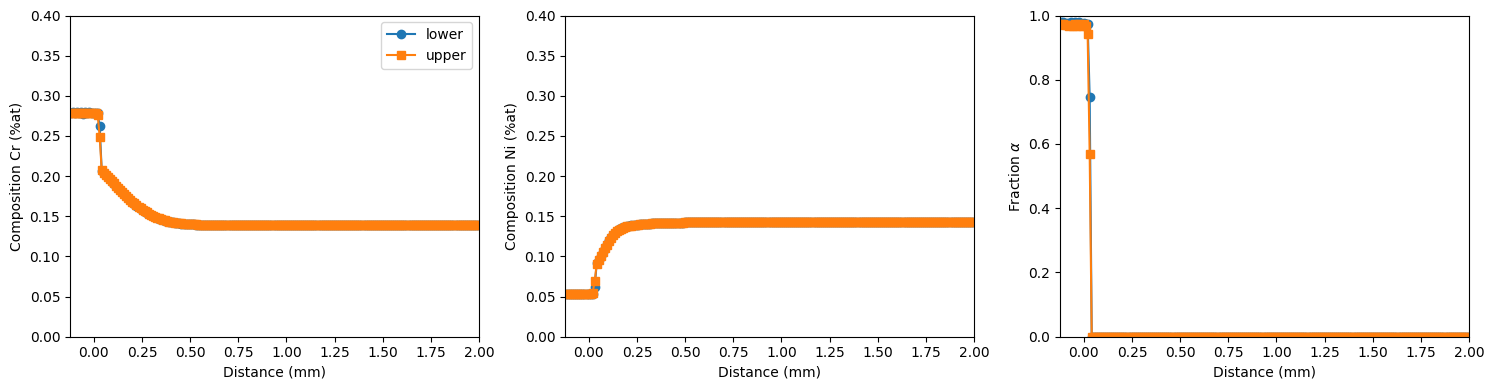

In [226]:
from kawin.diffusion.Plot import plot1D, plot1DPhases
fig, ax = plt.subplots(1,3, figsize=(15,4))

plot1D(ml, 'CR', zScale=1e-3, ax=ax[0], marker='o', label='lower')
plot1D(mu, 'CR', zScale=1e-3, ax=ax[0], marker='s', label='upper')
ax[0].set_xlabel('Distance (mm)')
ax[0].set_ylabel('Composition Cr (%at)')
ax[0].set_ylim([0, 0.40])
ax[0].legend()

plot1D(ml, 'NI', zScale=1e-3, ax=ax[1], marker='o', label='lower')
plot1D(mu, 'NI', zScale=1e-3, ax=ax[1], marker='s', label='upper')
ax[1].set_xlabel('Distance (mm)')
ax[1].set_ylabel('Composition Ni (%at)')
ax[1].set_ylim([0, 0.40])

plot1DPhases(ml, 'BCC_A2', zScale=1e-3, ax=ax[2], marker='o', label='lower')
plot1DPhases(mu, 'BCC_A2', zScale=1e-3, ax=ax[2], marker='s', label='upper')
ax[2].set_xlabel('Distance (mm)')
ax[2].set_ylabel(r'Fraction $\alpha$')
# ax[2].set_ylim([0, 0.8])
plt.tight_layout()
plt.show()

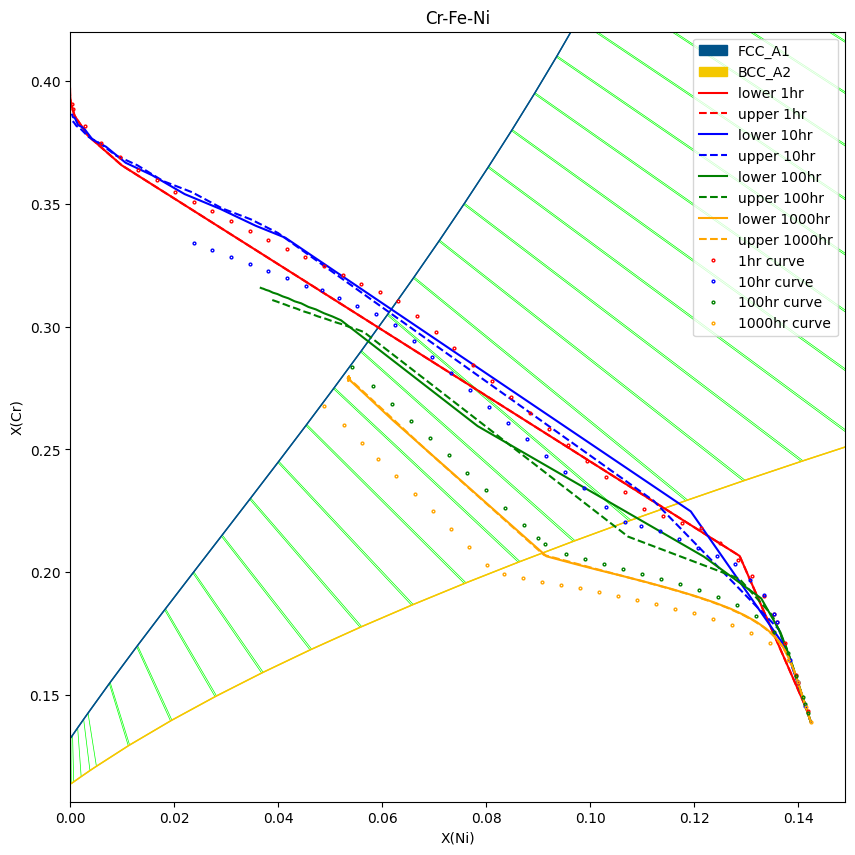

In [232]:
''' Comparison of homogenization model results with Lee and Oh's Fig 12b '''
from pycalphad import ternplot, variables as v
from pycalphad.plot import triangular
from pycalphad.plot.utils import phase_legend

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()
# ax = fig.add_subplot(projection='triangular')

conds = {v.T: temperature, v.P:101325, v.X('CR'): (0,1,0.015), v.X('NI'): (0,1,0.015)}
ternplot(therm.db, ['FE', 'CR', 'NI', 'VA'], phases, conds, x=v.X('NI'), y=v.X('CR'), ax = ax)


color_dict = {'1hr': 'red', '10hr': 'blue', '100hr': 'green', '1000hr': 'orange'}
linestyle_dict = {'lower': 'solid', 'upper': 'dashed'}
hndls_lst=[]
# Compositions will contain all elements (dependent, independent)
compl_1hr = ml.getCompositions(time=1*3600)
ln1, = ax.plot(compl_1hr[:,2], compl_1hr[:,1], label='lower 1hr', color=color_dict['1hr'], linestyle=linestyle_dict['lower']); hndls_lst.append(ln1)
compu_1hr = mu.getCompositions(time=1*3600)
ln2, = ax.plot(compu_1hr[:,2], compu_1hr[:,1], label='upper 1hr', color=color_dict['1hr'], linestyle=linestyle_dict['upper']); hndls_lst.append(ln2)

compl_10hr = ml.getCompositions(time=10*3600)
ln3, = ax.plot(compl_10hr[:,2], compl_10hr[:,1], label='lower 10hr', color=color_dict['10hr'], linestyle=linestyle_dict['lower']); hndls_lst.append(ln3)
compu_10hr = mu.getCompositions(time=10*3600)
ln4, = ax.plot(compu_10hr[:,2], compu_10hr[:,1], label='upper 10hr', color=color_dict['10hr'], linestyle=linestyle_dict['upper']); hndls_lst.append(ln4)

compl_100hr = ml.getCompositions(time=100*3600)
ln5, = ax.plot(compl_100hr[:,2], compl_100hr[:,1], label='lower 100hr', color=color_dict['100hr'], linestyle=linestyle_dict['lower']); hndls_lst.append(ln5)
compu_100hr = mu.getCompositions(time=100*3600)
ln6, = ax.plot(compu_100hr[:,2], compu_100hr[:,1], label='upper 100hr', color=color_dict['100hr'], linestyle=linestyle_dict['upper']); hndls_lst.append(ln6)

compl_1000hr = ml.getCompositions(time=1000*3600)
ln7, = ax.plot(compl_1000hr[:,2], compl_1000hr[:,1], label='lower 1000hr', color=color_dict['1000hr'], linestyle=linestyle_dict['lower']); hndls_lst.append(ln7)
compu_1000hr = mu.getCompositions(time=1000*3600)
ln8, = ax.plot(compu_1000hr[:,2], compu_1000hr[:,1], label='upper 1000hr', color=color_dict['1000hr'], linestyle=linestyle_dict['upper']); hndls_lst.append(ln8)



hr1, = ax.plot(fig12b_1hrCurve_df['X_NI'][::2], fig12b_1hrCurve_df['X_CR'][::2], 'o', markersize=2, fillstyle='none', color=color_dict['1hr'], label='1hr curve'); hndls_lst.append(hr1)
hr10, = ax.plot(fig12b_10hrCurve_df['X_NI'][::2], fig12b_10hrCurve_df['X_CR'][::2], 'o', markersize=2, fillstyle='none', color=color_dict['10hr'], label='10hr curve'); hndls_lst.append(hr10)
hr100, = ax.plot(fig12b_100hrCurve_df['X_NI'][::2], fig12b_100hrCurve_df['X_CR'][::2], 'o', markersize=2, fillstyle='none', color=color_dict['100hr'], label='100hr curve'); hndls_lst.append(hr100)
hr1000, = ax.plot(fig12b_1000hrCurve_df['X_NI'][::2], fig12b_1000hrCurve_df['X_CR'][::2], 'o', markersize=2, fillstyle='none', color=color_dict['1000hr'], label='1000hr curve'); hndls_lst.append(hr1000)

#The pycalphad ternplot function will automatically add a legend for the phases,
#but the legend has to be added again to add labels for the diffusion paths
handles, _ = phase_legend(phases)
ax.legend(handles = handles + hndls_lst)

ax.set_xlim(0, 0.149); ax.set_ylim(0.1066, 0.42)
plt.show()



In [237]:
# ml.data.y(1)
ml.getCurrentX()[0].shape
# ml.getdXdt()
type(ml)

kawin.diffusion.Homogenization.HomogenizationModel

Fluxes can be computed and plotted at the current state of the model.

Text(0.5, 0, 'Distance (mm)')

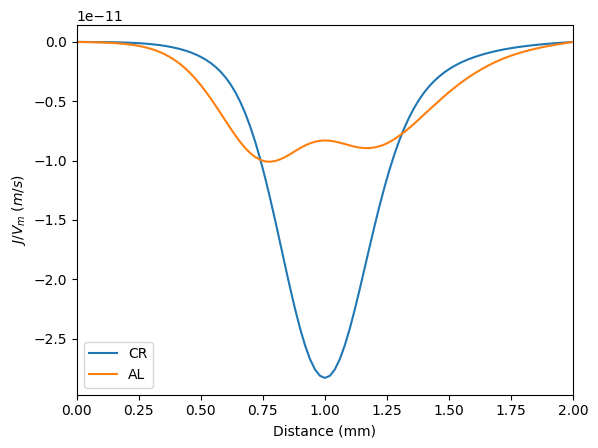

In [ ]:
from kawin.diffusion.Plot import plot1DFlux
fig, ax = plt.subplots()
plot1DFlux(m, ['CR', 'AL'], zScale=1e-3, ax=ax)
ax.set_xlabel('Distance (mm)')

### Replicating Lee And Oh Binary Results (Fig 8)


MovingBoundary1D state:
  interface_position = 374.5 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 374.5, 378.55]
  cut-cell widths = left 7.25, right 4.05
  center-to-interface distances = left 4.425, right 1.225
  local cells:
    [63] face=(355.95, 361.6) center=358.775 width=5.65 composition=0.291
    [64] face=(361.6, 367.25) center=364.425 width=5.65 composition=0.291
    [65] face=(367.25, 372.9) center=370.075 width=7.25 composition=0.291 <left of interface>
    [66] face=(372.9, 378.55) center=375.725 width=4.05 composition=0.394 <right of interface>
    [67] face=(378.55, 384.2) center=381.375 width=5.65 composition=0.394
    [68] face=(384.2, 389.85) center=387.025 width=5.65 composition=0.394


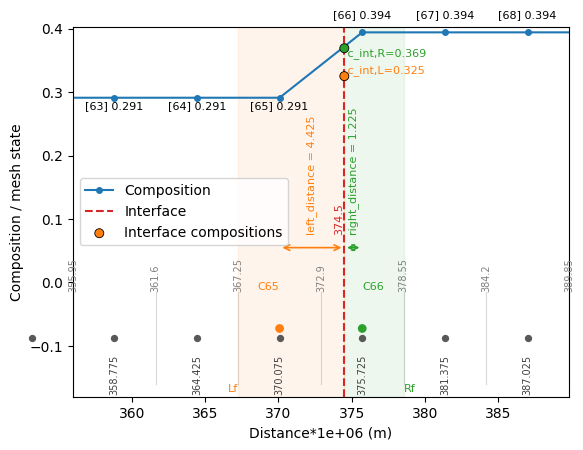

MovingBoundary1D state:
  interface_position = 374.5 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 374.5, 378.55]
  cut-cell widths = left 7.25, right 4.05
  center-to-interface distances = left 4.425, right 1.225
  local cells:
    [63] face=(355.95, 361.6) center=358.775 width=5.65 composition=0.291
    [64] face=(361.6, 367.25) center=364.425 width=5.65 composition=0.291
    [65] face=(367.25, 372.9) center=370.075 width=7.25 composition=0.291 <left of interface>
    [66] face=(372.9, 378.55) center=375.725 width=4.05 composition=0.394 <right of interface>
    [67] face=(378.55, 384.2) center=381.375 width=5.65 composition=0.394
    [68] face=(384.2, 389.85) center=387.025 width=5.65 composition=0.394


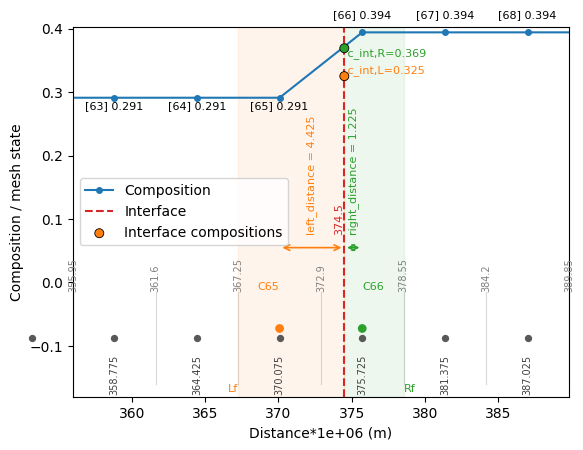

MovingBoundary1D state:
  interface_position = 374.5 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 374.5, 378.55]
  cut-cell widths = left 7.25, right 4.05
  center-to-interface distances = left 4.425, right 1.225
  local cells:
    [63] face=(355.95, 361.6) center=358.775 width=5.65 composition=0.291
    [64] face=(361.6, 367.25) center=364.425 width=5.65 composition=0.291
    [65] face=(367.25, 372.9) center=370.075 width=7.25 composition=0.291 <left of interface>
    [66] face=(372.9, 378.55) center=375.725 width=4.05 composition=0.394 <right of interface>
    [67] face=(378.55, 384.2) center=381.375 width=5.65 composition=0.394
    [68] face=(384.2, 389.85) center=387.025 width=5.65 composition=0.394
MovingBoundary1D state:
  interface_position = 373.0875 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 373.0875, 378.55]
  cut-cell widths = left 5.8375, right 5.4625
  center-to-interface distances = left 3.012

C:\Users\samth\OneDrive - Northwestern University\WS_DL\Lab Data\Price\code\kawin\kawin\PlotUtils.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


MovingBoundary1D state:
  interface_position = 371.384363 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 371.384363, 378.55]
  cut-cell widths = left 4.13436304, right 7.16563696
  center-to-interface distances = left 1.30936304, right 4.34063696
  local cells:
    [63] face=(355.95, 361.6) center=358.775 width=5.65 composition=0.291190787
    [64] face=(361.6, 367.25) center=364.425 width=5.65 composition=0.293348451
    [65] face=(367.25, 372.9) center=370.075 width=4.13436304 composition=0.310805196 <left of interface>
    [66] face=(372.9, 378.55) center=375.725 width=7.16563696 composition=0.372916758 <right of interface>
    [67] face=(378.55, 384.2) center=381.375 width=5.65 composition=0.377852938
    [68] face=(384.2, 389.85) center=387.025 width=5.65 composition=0.382310838
MovingBoundary1D state:
  interface_position = 371.344271 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 371.344271, 378.55]
  cut-

C:\Users\samth\OneDrive - Northwestern University\WS_DL\Lab Data\Price\code\kawin\kawin\PlotUtils.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


MovingBoundary1D state:
  interface_position = 370.774858 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 370.774858, 378.55]
  cut-cell widths = left 3.52485831, right 7.77514169
  center-to-interface distances = left 0.699858306, right 4.95014169
  local cells:
    [63] face=(355.95, 361.6) center=358.775 width=5.65 composition=0.291670571
    [64] face=(361.6, 367.25) center=364.425 width=5.65 composition=0.296184429
    [65] face=(367.25, 372.9) center=370.075 width=3.52485831 composition=0.319100595 <left of interface>
    [66] face=(372.9, 378.55) center=375.725 width=7.77514169 composition=0.372614115 <right of interface>
    [67] face=(378.55, 384.2) center=381.375 width=5.65 composition=0.376658087
    [68] face=(384.2, 389.85) center=387.025 width=5.65 composition=0.380440204
MovingBoundary1D state:
  interface_position = 370.746024 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 370.746024, 378.55]
  cut

C:\Users\samth\OneDrive - Northwestern University\WS_DL\Lab Data\Price\code\kawin\kawin\PlotUtils.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


MovingBoundary1D state:
  interface_position = 370.360081 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 370.360081, 378.55]
  cut-cell widths = left 3.11008063, right 8.18991937
  center-to-interface distances = left 0.285080635, right 5.36491937
  local cells:
    [63] face=(355.95, 361.6) center=358.775 width=5.65 composition=0.292165097
    [64] face=(361.6, 367.25) center=364.425 width=5.65 composition=0.298243863
    [65] face=(367.25, 372.9) center=370.075 width=3.11008063 composition=0.322932734 <left of interface>
    [66] face=(372.9, 378.55) center=375.725 width=8.18991937 composition=0.372511589 <right of interface>
    [67] face=(378.55, 384.2) center=381.375 width=5.65 composition=0.376160315
    [68] face=(384.2, 389.85) center=387.025 width=5.65 composition=0.379620647
MovingBoundary1D state:
  interface_position = 370.337211 between centers[65] = 370.075 and centers[66] = 375.725
  cut-cell faces = [367.25, 370.337211, 378.55]
  cut

In [ ]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2


from kawin.diffusion import SinglePhaseModel, HomogenizationModel, MovingBoundary1DModel, TemperatureParameters
from kawin.diffusion.mesh import Cartesian1D
from kawin.diffusion.mesh import ProfileBuilder, StepProfile1D
from kawin.tests.test_diffusion import ConstantBinaryThermodynamics
from kawin.solver import explicitEulerIterator

profile = ProfileBuilder([(StepProfile1D(374.5e-6, 0.291, 0.394), 'ZN')])
mesh = Cartesian1D(['ZN'], [0, 374.5e-6+190.5e-6], 100)
mesh.setResponseProfile(profile)
therm = ConstantBinaryThermodynamics(
    phases=['ALPHA', 'BETA'],
    diffusivities={'ALPHA': 5e-12, 'BETA': 1e-10},
    interface_compositions=(0.325, 0.369),
)

from kawin.diffusion.DiffusionParameters import DiffusionConstraints
constraints = DiffusionConstraints()
constraints.minComposition = 1e-10
constraints.movingBoundaryMassTolerance = 1e-7
constraints.movingBoundaryMassAction = 'raise'

model = MovingBoundary1DModel(
    mesh,
    ['CU', 'ZN'],
    ['ALPHA', 'BETA'],
    thermodynamics=therm,
    temperature=TemperatureParameters(1000),
    interfacePosition=374.5e-6,
    constraints=constraints,
    record=True,
)

initial_mass = model.getTotalMass()
model.solve(8e0, iterator=explicitEulerIterator)
final_mass = model.getTotalMass()


from kawin.diffusion.Plot import plot1D, plot1DPhases
fig, ax = plt.subplots(figsize=(15,4))

plot1D(model, 'ZN', time=0, zScale=1e-3, ax=ax, marker='o', label='t=initial')
plot1D(model, 'ZN', zScale=1e-3, ax=ax, marker='o', label='t=current')
ax.legend()
ax.set_ylim([0.25, 0.45])
# comp_init = model.getCompositions(time=0)
# ax.plot(comp_init[:,0], comp_init[:,1], label='t=initial')
# comp_current = model.getCompositions()
# ax.plot(comp_current[:,0], comp_current[:,1], label='t=current')
# ax.legend()

# comp_init[:,0], comp_init[:,1]
# model.getCompositions()

In [3]:
from kawin.diffusion import SinglePhaseModel
from kawin.diffusion.mesh import ProfileBuilder, StepProfile1D, Cartesian1D
from kawin.diffusion.Plot import plot1D, plot1DTwoAxis

from kawin.thermo import GeneralThermodynamics
therm = GeneralThermodynamics('FeCrNi.tdb', ['FE', 'CR', 'NI'], ['FCC_A1'])
therm.elements

#Define mesh spanning between -1mm to 1mm with 100 volume elements
mesh = Cartesian1D(['CR', 'NI'], [0, 2e-3], 6)

profile = ProfileBuilder()
# profile.addBuildStep(StepProfile1D(1e-3, [0.2, 0.4], [0.3, 0.3]), ['CR', 'NI'])
profile.addBuildStep(StepProfile1D(1e-3, [1e-8, 0.4], [0.3, 0.3]), ['CR', 'NI'])
mesh.setResponseProfile(profile)

print(mesh.y[0], mesh.y[-1])

from kawin.diffusion.DiffusionParameters import DiffusionConstraints
constraints = DiffusionConstraints()
constraints.minComposition = 1e-8

temperature = 1200+273.15
m = SinglePhaseModel(mesh, ['FE', 'CR', 'NI'], ['FCC_A1'], 
                     thermodynamics=therm, temperature=temperature, constraints=constraints, record=True)

print(m.mesh.y[0], m.mesh.y[-1])

[1.e-08 4.e-01] [0.3 0.3]
[1.0000000e-08 3.9999997e-01] [0.29999997 0.29999997]


### Periodic boundary conditions

Iteration	Sim Time (h)	Run time (s)
0		0.0e+00		0.0
100		2.8e+01		7.8
200		5.7e+01		14.7
300		8.9e+01		25.7
331		1.0e+02		30.1


(0.0, 0.1)

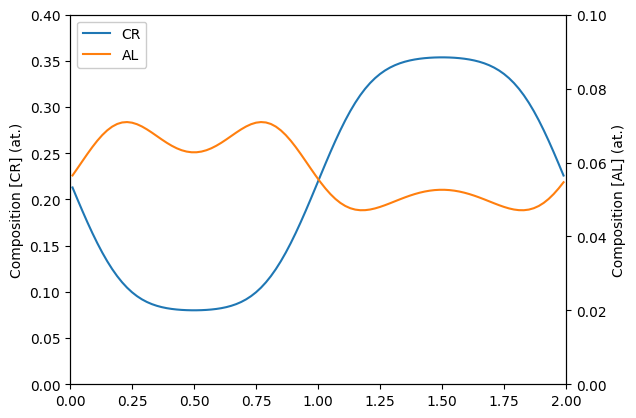

In [ ]:
from kawin.diffusion.mesh import PeriodicBoundary1D

mesh = Cartesian1D(['CR', 'AL'], [0, 2e-3], 100)
mesh.setResponseProfile(profile, boundaryConditions=PeriodicBoundary1D())
m = SinglePhaseModel(mesh, ['NI', 'CR', 'AL'], ['FCC_A1'], therm, temperature, record=False)
m.solve(100*3600, iterator=explicitEulerIterator, verbose=True, vIt=100)

fig, axL = plt.subplots()
axR = axL.twinx()
plot1DTwoAxis(m, 'CR', 'AL', zScale=1e-3, axL=axL, axR=axR)
axL.set_ylim([0, 0.4])
axR.set_ylim([0, 0.1])

### 2D mesh

Iteration	Sim Time (h)	Run time (s)
0		0.0e+00		0.0
10		5.6e+00		2.2
20		1.1e+01		8.4
30		1.7e+01		16.1
36		2.0e+01		21.6


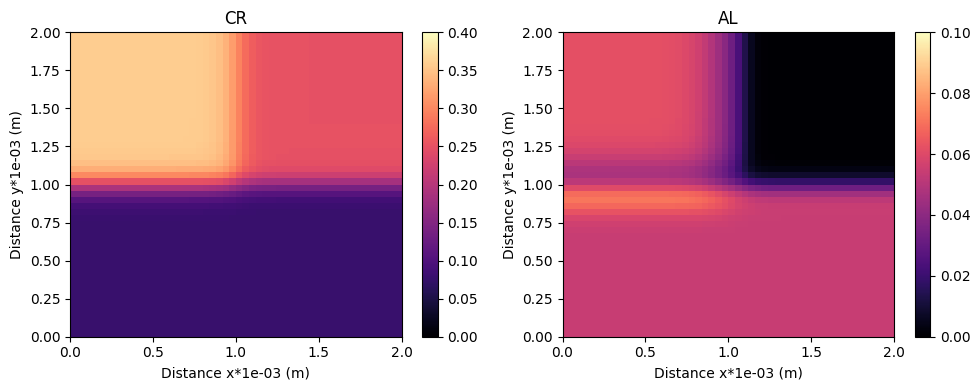

In [ ]:
from kawin.diffusion.mesh import Cartesian2D, BoundedRectangleProfile
from kawin.diffusion.Plot import plot2D

mesh = Cartesian2D(['CR', 'AL'], [0, 2e-3], 50, [0, 2e-3], 50)
profile2d = ProfileBuilder()
profile2d.addBuildStep(BoundedRectangleProfile([0,0], [2e-3, 1e-3], [0.077, 0.054]), ['CR', 'AL'])
profile2d.addBuildStep(BoundedRectangleProfile([0,1e-3], [1e-3, 2e-3], [0.359, 0.062]), ['CR', 'AL'])
profile2d.addBuildStep(BoundedRectangleProfile([1e-3,1e-3], [2e-3,2e-3], [0.25, 0.0]), ['CR', 'AL'])
mesh.setResponseProfile(profile2d)

m = SinglePhaseModel(mesh, ['NI', 'CR', 'AL'], ['FCC_A1'], therm, temperature, record=False)
m.solve(20*3600, iterator=explicitEulerIterator, verbose=True, vIt=10)

fig, ax = plt.subplots(1,2,figsize=(10,4))
_, cm = plot2D(m, 'CR', zScale=1e-3, ax=ax[0], cmap='magma', vmin=0, vmax=0.4)
fig.colorbar(cm, ax=ax[0])
_, cm = plot2D(m, 'AL', zScale=1e-3, ax=ax[1], cmap='magma', vmin=0, vmax=0.1)
fig.colorbar(cm, ax=ax[1])
fig.tight_layout()

## References

1. A. Borgenstam, A. Engstrom, L. Hoglund, J. Agren, "DICTRA, a Tool for Simulation of Diffusional Transformations in Alloys" *Journal of Phase Equilibria* 21 (2000) p. 269
2. A. Engstrom and J. Agren, "Assessment of Diffusional Mobilities in Face-Centered Cubic Ni-Cr-Al Alloys" *Z. Metallkd.* 87 (1996) p. 92